## Imports

Let's start by importing the required libraries.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["PATH"] = "/mnt/lustre-grete/usr/u12045/projects/LLAVA-Med/envs/lerobot/bin:" + os.environ.get("PATH", "")
os.environ["HF_HOME"] = "/mnt/lustre-grete/usr/u12045/vla/hf_cache"
os.environ["TMPDIR"] = "/mnt/lustre-grete/usr/u12045/vla/cache"
os.environ["PYTHONPATH"] = "/mnt/lustre-grete/usr/u12045/vla/duci/VLA-Humanoid:" + os.environ.get("PYTHONPATH", "")

from myutils.ground_sam_utils import *

%load_ext autoreload
%autoreload 2

2025-07-31 14:07:30.424676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753963650.777779 2724633 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753963650.903718 2724633 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753963651.704904 2724633 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753963651.704951 2724633 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753963651.704956 2724633 computation_placer.cc:177] computation placer alr

In [2]:
import torch
torch.cuda.is_available()

True

In [20]:
from lerobot.configs.train import TrainPipelineConfig
from lerobot.configs.policies import PreTrainedConfig
from lerobot.configs.default import DatasetConfig
from lerobot.common.datasets.factory import make_dataset


# /mnt/lustre-grete/usr/u12045/vla/hf_cache/lerobot/binhng/merged_libero_mask_noops_lerobot_10_v4
cfg = TrainPipelineConfig(
    policy=PreTrainedConfig.from_pretrained("lerobot/pi0"),
    dataset=DatasetConfig(
        repo_id=".",
        root="/mnt/lustre-grete/usr/u12045/vla/hf_cache/lerobot/ducido/calvin_task_D_D_scale_100_lerobo_format"
    ),
    wandb=None
)
cfg.validate()
cfg.dataset.image_transforms.enable = False
dataset = make_dataset(cfg)

The dataset you requested (.) is in 2.0 format.
While current version of LeRobot is backward-compatible with it, the version of your dataset still uses global
stats instead of per-episode stats. Update your dataset stats to the new format using this command:
```
python lerobot/common/datasets/v21/convert_dataset_v20_to_v21.py --repo-id=.
```

If you encounter a problem, contact LeRobot maintainers on [Discord](https://discord.com/invite/s3KuuzsPFb)
or open an [issue on GitHub](https://github.com/huggingface/lerobot/issues/new/choose).



The dataset you requested (.) is in 2.0 format.
While current version of LeRobot is backward-compatible with it, the version of your dataset still uses global
stats instead of per-episode stats. Update your dataset stats to the new format using this command:
```
python lerobot/common/datasets/v21/convert_dataset_v20_to_v21.py --repo-id=.
```

If you encounter a problem, contact LeRobot maintainers on [Discord](https://discord.com/invite/s3KuuzsPFb)
or open an [issue on GitHub](https://github.com/huggingface/lerobot/issues/new/choose).



Resolving data files:   0%|          | 0/5124 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/31 [00:00<?, ?it/s]

In [ ]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torchvision.transforms.functional as F

model_id = "IDEA-Research/grounding-dino-base"
device = 'cuda'
object_detector = pipeline(model=model_id, task="zero-shot-object-detection", device=device)

In [5]:
segmenter_id = "facebook/sam-vit-base"
segmentator = AutoModelForMaskGeneration.from_pretrained(segmenter_id).to(device)
processor = AutoProcessor.from_pretrained(segmenter_id)

In [30]:
def extract_obj_in_task(task: str, static_view: bool):
    # relevant_objects = ["the alphabet soup", "the cream cheese", "the basket"]
    # return relevant_objects + ["robot arm gripper"] if static_view else relevant_objects
    return ['the blue block']

def detect(image, labels, threshold=0.3):
    labels = [label if label.endswith(".") else label+"." for label in labels]
    results = object_detector(image,  candidate_labels=labels, threshold=threshold)
    results = [DetectionResult.from_dict(result) for result in results]
    return results

def segment(image, detection_results, polygon_refinement):
    boxes = get_boxes(detection_results)
    inputs = processor(images=image, input_boxes=boxes, return_tensors="pt").to(device)

    outputs = segmentator(**inputs)
    masks = processor.post_process_masks(
        masks=outputs.pred_masks,
        original_sizes=inputs.original_sizes,
        reshaped_input_sizes=inputs.reshaped_input_sizes
    )[0]

    masks = refine_masks(masks, polygon_refinement)

    for detection_result, mask in zip(detection_results, masks):
        detection_result.mask = mask

    return detection_results

for sample in dataset:
    task = sample['task']
    img = sample['image']
    img = F.to_pil_image(img)#.resize((800, 800))
    relevant_objects = extract_obj_in_task(task, static_view=True)

    detections = detect(img, labels=relevant_objects)
    # detections = segment(img, detections, polygon_refinement=True)
    break

In [10]:
task

'put both the alphabet soup and the cream cheese box in the basket'

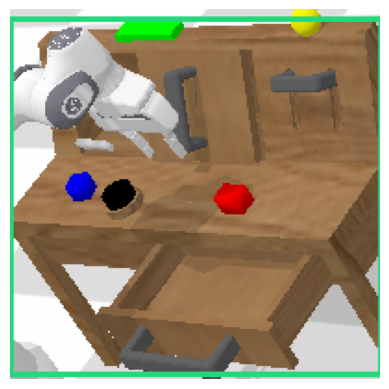

In [31]:
plot_detections(np.array(img), detections, "test.png")

In [25]:
np.array(img).shape

(256, 256, 3)

In [19]:
plot_detections_plotly(np.array(img), detections)

AttributeError: 'NoneType' object has no attribute 'astype'

In [20]:
np.array(img).shape

(256, 256, 3)